In [2]:
import pandas as pd
import numpy as np
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
orders = pd.read_csv('../data/raw/synthetic_orders.csv')
weather = pd.read_csv('../data/raw/delhi_weather_historical.csv')
events = pd.read_csv('../data/raw/delhi_events.csv')

with open('../data/raw/delhi_zones.json') as f:
    zones = json.load(f)

# Parse timestamps
orders['timestamp'] = pd.to_datetime(orders['timestamp'])
weather['timestamp'] = pd.to_datetime(weather['timestamp'])
events['date'] = pd.to_datetime(events['date'])

print(f"Orders shape:  {orders.shape}")
print(f"Weather shape: {weather.shape}")
print(f"Events shape:  {events.shape}")
print(f"Zones: {list(zones.keys())}")
print("\nOrders sample:")
print(orders.head(3))

Orders shape:  (25926, 7)
Weather shape: (336, 6)
Events shape:  (17, 3)
Zones: ['zone_1', 'zone_2', 'zone_3', 'zone_4', 'zone_5', 'zone_6']

Orders sample:
   timestamp zone_id                        zone_name  orders  hour  \
0 2024-01-01  zone_1  Connaught Place / Central Delhi      25     0   
1 2024-01-01  zone_2          South Delhi / Hauz Khas      35     0   
2 2024-01-01  zone_3             North Delhi / Rohini      19     0   

   day_of_week  is_weekend  
0            0       False  
1            0       False  
2            0       False  


In [3]:
orders.head()



,timestamp,zone_id,zone_name,orders,hour,day_of_week,is_weekend
0,2024-01-01,zone_1,Connaught Place / Central Delhi,25,0,0,False
1,2024-01-01,zone_2,South Delhi / Hauz Khas,35,0,0,False
2,2024-01-01,zone_3,North Delhi / Rohini,19,0,0,False
3,2024-01-01,zone_4,East Delhi / Laxmi Nagar,20,0,0,False
4,2024-01-01,zone_5,West Delhi / Rajouri Garden,19,0,0,False


In [4]:
weather.head()

,timestamp,temperature,humidity,precipitation,wind_speed,weather_code
0,2026-03-24 00:00:00,21.1,83,0.0,2.6,1
1,2026-03-24 01:00:00,21.1,83,0.0,1.0,2
2,2026-03-24 02:00:00,21.0,83,0.0,0.7,2
3,2026-03-24 03:00:00,20.8,83,0.0,0.8,1
4,2026-03-24 04:00:00,20.5,84,0.0,1.9,1


In [5]:
events.head()

,date,event,demand_multiplier
0,2024-10-31,Diwali,3.0
1,2024-11-01,Diwali Day 2,2.5
2,2024-03-25,Holi,2.0
3,2024-01-26,Republic Day,1.8
4,2024-08-15,Independence Day,1.8


In [4]:
def add_time_features(df):
    df = df.copy()
    df['hour']           = df['timestamp'].dt.hour
    df['day_of_week']    = df['timestamp'].dt.dayofweek
    df['day_of_month']   = df['timestamp'].dt.day
    df['month']          = df['timestamp'].dt.month
    df['is_weekend']     = df['day_of_week'] >= 5
    df['is_lunch']       = df['hour'].between(12, 14)
    df['is_dinner']      = df['hour'].between(19, 22)
    df['is_breakfast']   = df['hour'].between(7, 9)
    df['is_late_night']  = (df['hour'] >= 23) | (df['hour'] <= 5)
    df['is_peak']        = df['is_lunch'] | df['is_dinner']
    
    # Cyclical encoding — tells model that hour 23 is close to hour 0
    df['hour_sin']       = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']       = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']        = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']        = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    return df

orders = add_time_features(orders)
print(f"Time features added. New shape: {orders.shape}")
print(f"New columns: {[c for c in orders.columns if c not in ['timestamp','zone_id','zone_name','orders']]}")

Time features added. New shape: (25926, 18)
New columns: ['hour', 'day_of_week', 'is_weekend', 'day_of_month', 'month', 'is_lunch', 'is_dinner', 'is_breakfast', 'is_late_night', 'is_peak', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [5]:
orders.head()

,timestamp,zone_id,zone_name,orders,hour,day_of_week,is_weekend,day_of_month,month,is_lunch,is_dinner,is_breakfast,is_late_night,is_peak,hour_sin,hour_cos,dow_sin,dow_cos
0,2024-01-01,zone_1,Connaught Place / Central Delhi,25,0,0,False,1,1,False,False,False,True,False,0.0,1.0,0.0,1.0
1,2024-01-01,zone_2,South Delhi / Hauz Khas,35,0,0,False,1,1,False,False,False,True,False,0.0,1.0,0.0,1.0
2,2024-01-01,zone_3,North Delhi / Rohini,19,0,0,False,1,1,False,False,False,True,False,0.0,1.0,0.0,1.0
3,2024-01-01,zone_4,East Delhi / Laxmi Nagar,20,0,0,False,1,1,False,False,False,True,False,0.0,1.0,0.0,1.0
4,2024-01-01,zone_5,West Delhi / Rajouri Garden,19,0,0,False,1,1,False,False,False,True,False,0.0,1.0,0.0,1.0


In [6]:
def add_event_features(df, events_df):
    df = df.copy()
    df['date'] = df['timestamp'].dt.date
    df['date'] = pd.to_datetime(df['date'])
    
    # Merge event multipliers
    df = df.merge(
        events_df[['date', 'event', 'demand_multiplier']],
        on='date',
        how='left'
    )
    
    df['is_festival']        = df['event'].notna()
    df['demand_multiplier']  = df['demand_multiplier'].fillna(1.0)
    df['event']              = df['event'].fillna('normal')
    
    # Is it a major festival (multiplier > 2)?
    df['is_major_festival']  = df['demand_multiplier'] > 2.0
    
    # Is it IPL season (April-May)?
    df['is_ipl_season']      = df['month'].isin([4, 5])
    
    # Is it monsoon season (July-September)?
    df['is_monsoon']         = df['month'].isin([7, 8, 9])
    
    return df

orders = add_event_features(orders, events)
print(f"Event features added. New shape: {orders.shape}")
print(f"\nFestival days in data:")
print(orders[orders['is_festival']][['timestamp', 'zone_id', 'event', 'demand_multiplier']].head(6))

Event features added. New shape: (25926, 25)

Festival days in data:
   timestamp zone_id     event  demand_multiplier
0 2024-01-01  zone_1  New Year                2.5
1 2024-01-01  zone_2  New Year                2.5
2 2024-01-01  zone_3  New Year                2.5
3 2024-01-01  zone_4  New Year                2.5
4 2024-01-01  zone_5  New Year                2.5
5 2024-01-01  zone_6  New Year                2.5


In [9]:
orders.head()

,timestamp,zone_id,zone_name,orders,hour,day_of_week,is_weekend,day_of_month,month,is_lunch,...,hour_cos,dow_sin,dow_cos,date,event,demand_multiplier,is_festival,is_major_festival,is_ipl_season,is_monsoon
0,2024-01-01,zone_1,Connaught Place / Central Delhi,25,0,0,False,1,1,False,...,1.0,0.0,1.0,2024-01-01,New Year,2.5,True,True,False,False
1,2024-01-01,zone_2,South Delhi / Hauz Khas,35,0,0,False,1,1,False,...,1.0,0.0,1.0,2024-01-01,New Year,2.5,True,True,False,False
2,2024-01-01,zone_3,North Delhi / Rohini,19,0,0,False,1,1,False,...,1.0,0.0,1.0,2024-01-01,New Year,2.5,True,True,False,False
3,2024-01-01,zone_4,East Delhi / Laxmi Nagar,20,0,0,False,1,1,False,...,1.0,0.0,1.0,2024-01-01,New Year,2.5,True,True,False,False
4,2024-01-01,zone_5,West Delhi / Rajouri Garden,19,0,0,False,1,1,False,...,1.0,0.0,1.0,2024-01-01,New Year,2.5,True,True,False,False


In [7]:
def add_zone_features(df, zones_dict):
    df = df.copy()
    
    # Map zone attributes
    df['zone_base_demand'] = df['zone_id'].map(
        {zid: z['base_demand'] for zid, z in zones_dict.items()}
    )
    df['zone_type'] = df['zone_id'].map(
        {zid: z['type'] for zid, z in zones_dict.items()}
    )
    
    # Encode zone type
    zone_type_map = {
        'commercial': 0,
        'residential_affluent': 1,
        'residential': 2,
        'mixed': 3,
        'tech_hub': 4
    }
    df['zone_type_encoded'] = df['zone_type'].map(zone_type_map)
    
    # Zone ID encoded
    df['zone_encoded'] = df['zone_id'].str.replace('zone_', '').astype(int)
    
    return df

orders = add_zone_features(orders, zones)
print(f"Zone features added. New shape: {orders.shape}")
print(orders[['zone_id', 'zone_type', 'zone_base_demand', 'zone_encoded']].drop_duplicates())

Zone features added. New shape: (25926, 29)
  zone_id             zone_type  zone_base_demand  zone_encoded
0  zone_1            commercial               120             1
1  zone_2  residential_affluent               150             2
2  zone_3           residential                90             3
3  zone_4           residential                85             4
4  zone_5                 mixed               100             5
5  zone_6              tech_hub               130             6


In [8]:
def add_lag_features(df):
    df = df.copy()
    df = df.sort_values(['zone_id', 'timestamp']).reset_index(drop=True)
    
    # Previous demand per zone
    # Lag 1 = demand 30 minutes ago
    # Lag 2 = demand 1 hour ago
    # Lag 48 = demand same time yesterday
    for lag in [1, 2, 4, 48]:
        df[f'orders_lag_{lag}'] = df.groupby('zone_id')['orders'].shift(lag)
    
    # Rolling averages per zone
    df['orders_rolling_mean_4']  = df.groupby('zone_id')['orders'].transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).mean()
    )
    df['orders_rolling_mean_48'] = df.groupby('zone_id')['orders'].transform(
        lambda x: x.shift(1).rolling(48, min_periods=1).mean()
    )
    
    # Drop rows with NaN lags
    df = df.dropna(subset=['orders_lag_48'])
    
    return df

orders = add_lag_features(orders)
print(f"Lag features added. New shape: {orders.shape}")
print(f"Lag columns: {[c for c in orders.columns if 'lag' in c or 'rolling' in c]}")

Lag features added. New shape: (25638, 35)
Lag columns: ['orders_lag_1', 'orders_lag_2', 'orders_lag_4', 'orders_lag_48', 'orders_rolling_mean_4', 'orders_rolling_mean_48']


In [9]:
# Final feature columns for model
feature_cols = [
    # Time features
    'hour', 'day_of_week', 'month', 'day_of_month',
    'is_weekend', 'is_lunch', 'is_dinner', 'is_breakfast',
    'is_late_night', 'is_peak',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    
    # Event features
    'is_festival', 'demand_multiplier', 'is_major_festival',
    'is_ipl_season', 'is_monsoon',
    
    # Zone features
    'zone_base_demand', 'zone_type_encoded', 'zone_encoded',
    
    # Lag features
    'orders_lag_1', 'orders_lag_2', 'orders_lag_4', 'orders_lag_48',
    'orders_rolling_mean_4', 'orders_rolling_mean_48'
]

# Convert boolean to int
bool_cols = ['is_weekend', 'is_lunch', 'is_dinner', 'is_breakfast',
             'is_late_night', 'is_peak', 'is_festival',
             'is_major_festival', 'is_ipl_season', 'is_monsoon']
for col in bool_cols:
    orders[col] = orders[col].astype(int)

X = orders[feature_cols]
y = orders['orders']

print(f"Feature matrix: {X.shape}")
print(f"Target: {y.shape}")
print(f"\nFeature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

Feature matrix: (25638, 28)
Target: (25638,)

Feature columns (28):
   1. hour
   2. day_of_week
   3. month
   4. day_of_month
   5. is_weekend
   6. is_lunch
   7. is_dinner
   8. is_breakfast
   9. is_late_night
  10. is_peak
  11. hour_sin
  12. hour_cos
  13. dow_sin
  14. dow_cos
  15. is_festival
  16. demand_multiplier
  17. is_major_festival
  18. is_ipl_season
  19. is_monsoon
  20. zone_base_demand
  21. zone_type_encoded
  22. zone_encoded
  23. orders_lag_1
  24. orders_lag_2
  25. orders_lag_4
  26. orders_lag_48
  27. orders_rolling_mean_4
  28. orders_rolling_mean_48


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import joblib

# Train/test split — use last 20% of time as test (time-based split)
split_idx = int(len(orders) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Testing set:  {X_test.shape[0]:,} rows")

# Train model
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost model...")
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

# Evaluate
y_pred = model.predict(X_test)
mae    = mean_absolute_error(y_test, y_pred)
r2     = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"  MAE: {mae:.2f} orders")
print(f"  R²:  {r2:.3f}")
print(f"\nInterpretation:")
print(f"  Predictions are within ±{mae:.0f} orders on average")
print(f"  Model explains {r2*100:.0f}% of demand variation")

Training set: 20,510 rows
Testing set:  5,128 rows

Training XGBoost model...
[0]	validation_0-rmse:125.50110
[50]	validation_0-rmse:50.15296
[100]	validation_0-rmse:47.43669
[150]	validation_0-rmse:47.92393
[200]	validation_0-rmse:48.31168
[250]	validation_0-rmse:48.47641
[299]	validation_0-rmse:48.56844

Model Performance:
  MAE: 25.41 orders
  R²:  0.857

Interpretation:
  Predictions are within ±25 orders on average
  Model explains 86% of demand variation


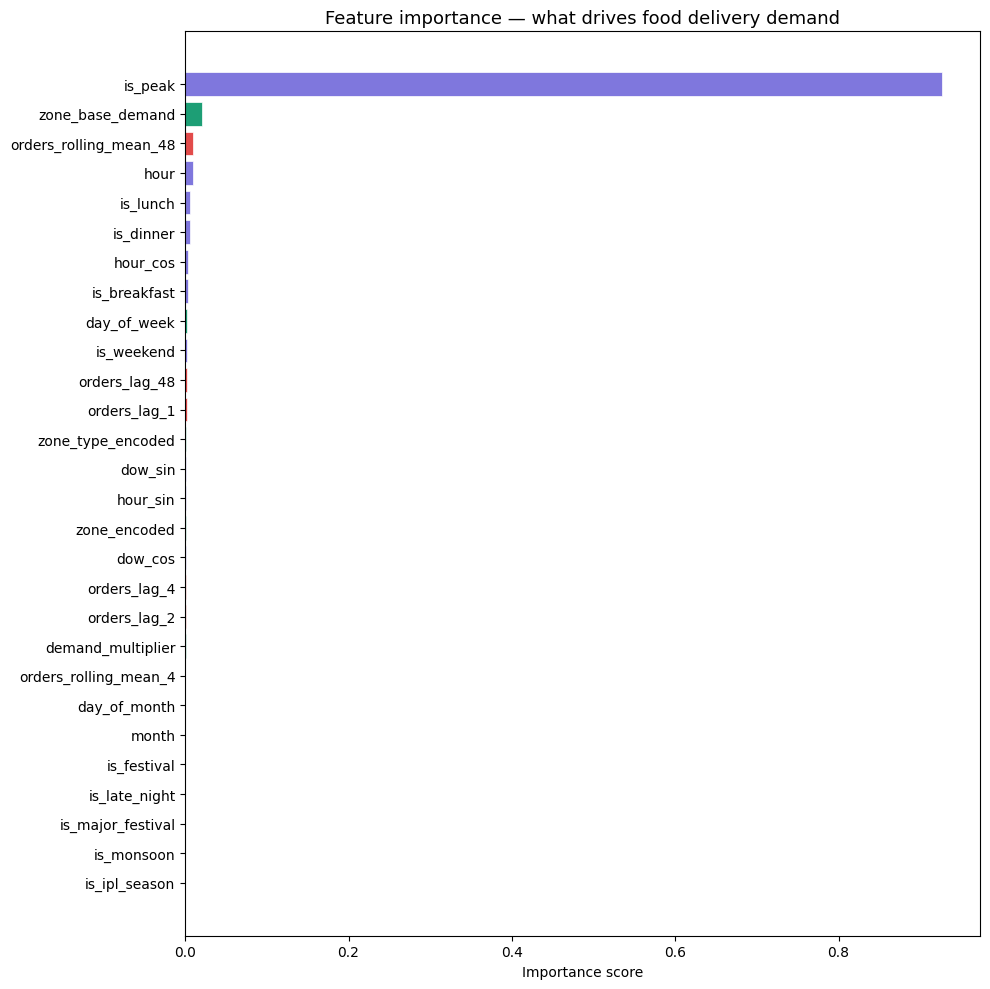

Feature importance chart saved!

Top 5 most important features:
               feature  importance
              is_lunch    0.006100
                  hour    0.009120
orders_rolling_mean_48    0.009497
      zone_base_demand    0.021106
               is_peak    0.926829


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Create folder if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

importance = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#E24B4A' if 'lag' in f or 'rolling' in f
          else '#7F77DD' if 'hour' in f or 'dow' in f or 'is_' in f
          else '#1D9E75'
          for f in importance['feature']]

ax.barh(importance['feature'], importance['importance'],
        color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Feature importance — what drives food delivery demand', fontsize=13)
ax.set_xlabel('Importance score')

plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=120)
plt.show()
print("Feature importance chart saved!")

print("\nTop 5 most important features:")
print(importance.tail(5)[['feature', 'importance']].to_string(index=False))

In [12]:
import joblib
import json
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Save model
joblib.dump(model, '../models/baseline_model.pkl')

# Save processed orders
orders.to_csv('../data/processed/orders_featured.csv', index=False)

# Save feature column list
with open('../models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("=== STEP 3 COMPLETE ===")
print(f"\nModel saved:          models/baseline_model.pkl")
print(f"Featured data saved:  data/processed/orders_featured.csv")
print(f"Feature list saved:   models/feature_cols.json")
print(f"\nModel R²:  {r2:.3f}")
print(f"Model MAE: {mae:.2f} orders")
print(f"\nReady for Step 4 — Kafka Streaming Pipeline!")

=== STEP 3 COMPLETE ===

Model saved:          models/baseline_model.pkl
Featured data saved:  data/processed/orders_featured.csv
Feature list saved:   models/feature_cols.json

Model R²:  0.857
Model MAE: 25.41 orders

Ready for Step 4 — Kafka Streaming Pipeline!
